🚀 Using device: cpu

📤 Upload cnn_features.pkl:


Saving cnn_features.pkl to cnn_features.pkl
✅ CNN features loaded
   Train : (1924, 256)
   Val   : (966, 256)
   Test  : (966, 256)
   Feature dim: 256


100%|██████████| 2.52M/2.52M [00:00<00:00, 121MB/s]

Extracting files...



✅ Tabular dataset loaded: (120000, 17)
   Target column: Diagnosis
   Clinical features: 15

✅ Tabular split:
   Train: (84000, 15) | Val: (18000, 15) | Test: (18000, 15)

🔗 Fusing CNN + Clinical features...

✅ Fused feature vectors:
   CNN features     : 256
   Clinical features: 15
   Combined dim     : 271  ← MLP input size
   Train : (1924, 271)
   Val   : (966, 271)
   Test  : (966, 271)

🧠 Fusion MLP Architecture:
FusionMLP(
  (net): Sequential(
    (0): Linear(in_features=271, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, tra

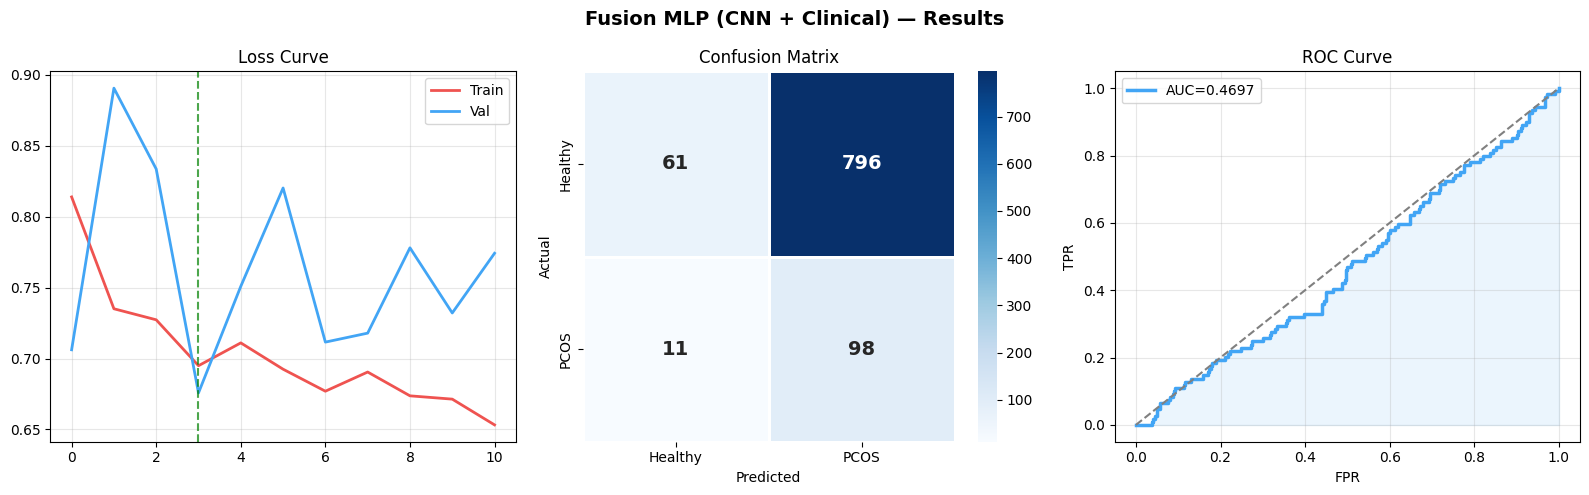


💾 Saved: fusion_model_complete.pt

🏆 FUSION MODEL COMPLETE!
   AUC : 0.4697
   F1  : 0.1954


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads started!


In [1]:
import os, glob, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             f1_score, accuracy_score)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import kagglehub
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {DEVICE}")

# ================================
# STEP 1: LOAD CNN FEATURES
# Upload cnn_features.pkl first!
# ================================
from google.colab import files

print("\n📤 Upload cnn_features.pkl:")
uploaded = files.upload()

with open('cnn_features.pkl', 'rb') as f:
    cnn_data = pickle.load(f)

CNN_FEATURE_DIM = cnn_data['feature_dim']
print(f"✅ CNN features loaded")
print(f"   Train : {cnn_data['train_feats'].shape}")
print(f"   Val   : {cnn_data['val_feats'].shape}")
print(f"   Test  : {cnn_data['test_feats'].shape}")
print(f"   Feature dim: {CNN_FEATURE_DIM}")

# ================================
# STEP 2: LOAD TABULAR DATA
# ================================
path = kagglehub.dataset_download("ankushpanday1/pcos-prediction-datasettop-75-countries")
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)
df = pd.read_csv(csv_files[0])
print(f"\n✅ Tabular dataset loaded: {df.shape}")

# ── Target detection ──
possible_targets = ['PCOS', 'pcos', 'diagnosis', 'target', 'label', 'PCOS (Y/N)', 'Diagnosis']
TARGET_COL = None
for col in df.columns:
    if col.strip().lower().replace(" ", "_") in [t.lower() for t in possible_targets]:
        TARGET_COL = col
        break
if TARGET_COL is None:
    TARGET_COL = 'Diagnosis'
print(f"   Target column: {TARGET_COL}")

# ================================
# STEP 3: PREPROCESS TABULAR DATA
# ================================
df_clean = df.copy()

# Drop ID-like columns
id_cols = [col for col in df_clean.columns
           if df_clean[col].nunique() > 0.95 * len(df_clean)]
if id_cols:
    df_clean.drop(columns=id_cols, inplace=True)

# Encode target
le_target = LabelEncoder()
df_clean[TARGET_COL] = le_target.fit_transform(df_clean[TARGET_COL])

# Fill missing values
for col in df_clean.columns:
    if df_clean[col].dtype == object:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Encode categoricals
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

feature_names = df_clean.drop(columns=[TARGET_COL]).columns.tolist()
print(f"   Clinical features: {len(feature_names)}")

X_tab = df_clean.drop(columns=[TARGET_COL]).values.astype(np.float32)
y_tab = df_clean[TARGET_COL].values.astype(np.float32)

# ── Split tabular data same way ──
X_train_tab, X_temp_tab, y_train_tab, y_temp_tab = train_test_split(
    X_tab, y_tab, test_size=0.3, stratify=y_tab, random_state=SEED)
X_val_tab, X_test_tab, y_val_tab, y_test_tab = train_test_split(
    X_temp_tab, y_temp_tab, test_size=0.5,
    stratify=y_temp_tab, random_state=SEED)

# Scale tabular features
scaler_tab = StandardScaler()
X_train_tab = scaler_tab.fit_transform(X_train_tab)
X_val_tab   = scaler_tab.transform(X_val_tab)
X_test_tab  = scaler_tab.transform(X_test_tab)

print(f"\n✅ Tabular split:")
print(f"   Train: {X_train_tab.shape} | Val: {X_val_tab.shape} | Test: {X_test_tab.shape}")

# ================================
# STEP 4: ALIGN SIZES & CONCATENATE
# ================================
# CNN and tabular datasets have different sizes
# We align by taking min size and concatenating

def align_and_concat(cnn_feats, tab_feats, labels_cnn, labels_tab):
    """
    Align CNN features with tabular features.
    Since datasets differ in size, we sample to match.
    Labels from tabular data are used (both are PCOS datasets).
    """
    min_size = min(len(cnn_feats), len(tab_feats))

    # Take first min_size samples (already shuffled during split)
    cnn_feats = cnn_feats[:min_size]
    tab_feats = tab_feats[:min_size]
    labels    = labels_tab[:min_size]   # use tabular labels

    # Normalize CNN features
    scaler_cnn = StandardScaler()
    cnn_feats_scaled = scaler_cnn.fit_transform(cnn_feats)

    # Concatenate: [CNN 256-dim] + [Clinical N-dim]
    fused = np.concatenate([cnn_feats_scaled, tab_feats], axis=1)

    return fused, labels, scaler_cnn


print("\n🔗 Fusing CNN + Clinical features...")

X_train_fused, y_train_f, scaler_cnn_train = align_and_concat(
    cnn_data['train_feats'], X_train_tab,
    cnn_data['train_labels'], y_train_tab)

# For val and test, use same CNN scaler
def align_and_concat_transform(cnn_feats, tab_feats, labels_tab, scaler_cnn):
    min_size = min(len(cnn_feats), len(tab_feats))
    cnn_feats = cnn_feats[:min_size]
    tab_feats = tab_feats[:min_size]
    labels    = labels_tab[:min_size]
    cnn_feats_scaled = scaler_cnn.transform(cnn_feats)
    fused = np.concatenate([cnn_feats_scaled, tab_feats], axis=1)
    return fused, labels

X_val_fused,  y_val_f  = align_and_concat_transform(
    cnn_data['val_feats'],  X_val_tab,  y_val_tab,  scaler_cnn_train)
X_test_fused, y_test_f = align_and_concat_transform(
    cnn_data['test_feats'], X_test_tab, y_test_tab, scaler_cnn_train)

FUSED_DIM = X_train_fused.shape[1]
print(f"\n✅ Fused feature vectors:")
print(f"   CNN features     : {CNN_FEATURE_DIM}")
print(f"   Clinical features: {len(feature_names)}")
print(f"   Combined dim     : {FUSED_DIM}  ← MLP input size")
print(f"   Train : {X_train_fused.shape}")
print(f"   Val   : {X_val_fused.shape}")
print(f"   Test  : {X_test_fused.shape}")

# ================================
# STEP 5: FUSION MLP MODEL
# ================================
class FusionMLP(nn.Module):
    """
    MLP that takes FUSED input:
    [CNN image features (256)] + [Clinical tabular features (N)]

    Architecture:
        Input(FUSED_DIM) → FC(512) → BN → ReLU → Dropout
                         → FC(256) → BN → ReLU → Dropout
                         → FC(128) → BN → ReLU → Dropout
                         → FC(64)  → BN → ReLU → Dropout
                         → FC(1)   → Sigmoid
    """
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout / 2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


fusion_model = FusionMLP(FUSED_DIM, dropout=0.3).to(DEVICE)
print(f"\n🧠 Fusion MLP Architecture:")
print(fusion_model)
print(f"\n⚙️  Input dim  : {FUSED_DIM} (CNN {CNN_FEATURE_DIM} + Clinical {len(feature_names)})")
print(f"⚙️  Parameters : {fusion_model.count_parameters():,}")

# ================================
# STEP 6: DATALOADERS
# ================================
def make_loader(X, y, batch_size=64, sampler=None, shuffle=False):
    X_t = torch.FloatTensor(X.astype(np.float32)).to(DEVICE)
    y_t = torch.FloatTensor(y.astype(np.float32)).to(DEVICE)
    ds  = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size,
                      sampler=sampler, shuffle=shuffle)

# Weighted sampler for class imbalance
class_counts   = np.bincount(y_train_f.astype(int))
weights        = 1.0 / class_counts
sample_weights = weights[y_train_f.astype(int)]
sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_f = make_loader(X_train_fused, y_train_f, sampler=sampler)
val_loader_f   = make_loader(X_val_fused,   y_val_f,   shuffle=False)
test_loader_f  = make_loader(X_test_fused,  y_test_f,  shuffle=False)

print(f"\n✅ DataLoaders ready")
print(f"   Train batches : {len(train_loader_f)}")
print(f"   Val batches   : {len(val_loader_f)}")
print(f"   Class 0 (Healthy): {class_counts[0]} | Class 1 (PCOS): {class_counts[1]}")

# ================================
# STEP 7: TRAINING
# ================================
criterion  = nn.BCELoss()
optimizer  = optim.Adam(fusion_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5)

best_val_loss = float('inf')
patience_es   = 7
counter_es    = 0
best_epoch    = 0
train_losses, val_losses = [], []
EPOCHS = 50

print(f"\n{'='*60}")
print(f"🚀 Training Fusion MLP — {EPOCHS} epochs max")
print(f"{'='*60}")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val Acc':>8}")
print("-"*45)

for epoch in range(1, EPOCHS + 1):
    # Train
    fusion_model.train()
    train_loss = 0
    for xb, yb in train_loader_f:
        optimizer.zero_grad(set_to_none=True)
        out  = fusion_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_f)

    # Validate
    fusion_model.eval()
    val_loss = 0
    correct  = 0
    total    = 0
    with torch.no_grad():
        for xb, yb in val_loader_f:
            out   = fusion_model(xb)
            loss  = criterion(out, yb)
            val_loss += loss.item()
            preds     = (out >= 0.5).float()
            correct  += (preds == yb).sum().item()
            total    += yb.size(0)

    val_loss /= len(val_loader_f)
    val_acc   = correct / total
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | {val_acc*100:>7.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        counter_es    = 0
        torch.save(fusion_model.state_dict(), "fusion_model_best.pt")
        print(f"   💾 Saved (val_loss={val_loss:.4f})")
    else:
        counter_es += 1
        if counter_es >= patience_es:
            print(f"\n🛑 Early stopping at epoch {epoch}")
            break

print(f"\n✅ Training done! Best epoch: {best_epoch}")

# ================================
# STEP 8: EVALUATION
# ================================
fusion_model.load_state_dict(torch.load("fusion_model_best.pt"))
fusion_model.eval()

y_pred_f, y_true_f, y_prob_f = [], [], []
with torch.no_grad():
    for xb, yb in test_loader_f:
        out  = fusion_model(xb)
        prob = out.cpu().numpy()
        pred = (out >= 0.5).float().cpu().numpy()
        y_prob_f.extend(prob)
        y_pred_f.extend(pred)
        y_true_f.extend(yb.cpu().numpy())

y_pred_f = np.array(y_pred_f).flatten()
y_true_f = np.array(y_true_f).flatten()
y_prob_f = np.array(y_prob_f).flatten()

# Threshold tuning
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.3, 0.7, 0.05):
    tmp = (y_prob_f > t).astype(int)
    f1  = f1_score(y_true_f, tmp, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

y_pred_f = (y_prob_f > best_thresh).astype(int)

print(f"\n{'='*55}")
print(f"📊 FUSION MODEL — TEST RESULTS")
print(f"{'='*55}")
print(f"  Accuracy  : {accuracy_score(y_true_f, y_pred_f)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_true_f, y_pred_f)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_true_f, y_prob_f):.4f}")
print(f"  Threshold : {best_thresh:.3f}")
print(f"{'='*55}")
print(f"\n{classification_report(y_true_f, y_pred_f, target_names=['No PCOS','PCOS'])}")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fusion MLP (CNN + Clinical) — Results', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(train_losses, label='Train', color='#EF5350', linewidth=2)
axes[0].plot(val_losses,   label='Val',   color='#42A5F5', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='green', linestyle='--', alpha=0.7)
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_true_f, y_pred_f)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Healthy','PCOS'], yticklabels=['Healthy','PCOS'],
            linewidths=2, linecolor='white', annot_kws={'size':14,'weight':'bold'})
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# ROC
fpr, tpr, _ = roc_curve(y_true_f, y_prob_f)
auc_score   = roc_auc_score(y_true_f, y_prob_f)
axes[2].plot(fpr, tpr, color='#42A5F5', linewidth=2.5, label=f'AUC={auc_score:.4f}')
axes[2].plot([0,1],[0,1],'--', color='gray')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='#42A5F5')
axes[2].set_title('ROC Curve'); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')

plt.tight_layout()
plt.savefig('fusion_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================
# STEP 9: SAVE FUSION MODEL
# ================================
torch.save({
    'model_state_dict' : fusion_model.state_dict(),
    'fused_dim'        : FUSED_DIM,
    'cnn_feature_dim'  : CNN_FEATURE_DIM,
    'clinical_dim'     : len(feature_names),
    'feature_names'    : feature_names,
    'best_threshold'   : float(best_thresh),
    'best_epoch'       : best_epoch,
    'test_auc'         : float(auc_score),
    'test_f1'          : float(best_f1),
    'test_accuracy'    : float(accuracy_score(y_true_f, y_pred_f)),
    'scaler_tab'       : scaler_tab,
    'scaler_cnn'       : scaler_cnn_train,
}, 'fusion_model_complete.pt')

print("\n💾 Saved: fusion_model_complete.pt")
print(f"\n🏆 FUSION MODEL COMPLETE!")
print(f"   AUC : {auc_score:.4f}")
print(f"   F1  : {best_f1:.4f}")

from google.colab import files
files.download('fusion_model_complete.pt')
files.download('fusion_results.png')
print("✅ Downloads started!")